# Data Preparation

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Data

In [108]:
# Load effort time series data
# effort_ts = pd.read_parquet('../../data/raw/effort_ts.parquet')
# pos_ts = pd.read_parquet('../../data/raw/pos_ts.parquet')

print(f"Loaded pos_ts: {pos_ts.shape}")
print(f"Columns: {pos_ts.columns.tolist()}")

Loaded pos_ts: (10405592, 16)
Columns: ['participantID', 'trialName', 'trial', 'threat', 'choice', 'outcome', 'startDistance', 'effort_L', 'effort_H', 'distance_L', 'distance_H', 'isAttackTrial', 'agent', 't', 'x', 'y']


## 2. Plot Histogram of calibrationMax

In [18]:
# Get one calibrationMax per participant
calib_per_subj = effort_ts.groupby('participantID')['calibrationMax'].first().reset_index()

print(f"Number of participants: {len(calib_per_subj)}")
print(f"\ncalibrationMax stats:")
print(calib_per_subj['calibrationMax'].describe())

Number of participants: 293

calibrationMax stats:
count    293.000000
mean       6.800683
std        1.418759
min        1.300000
25%        6.100000
50%        6.900000
75%        7.900000
max        8.900000
Name: calibrationMax, dtype: float64


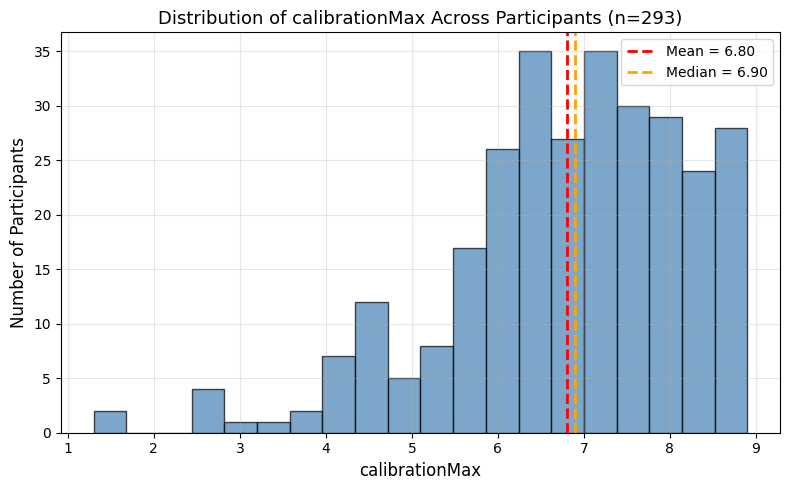

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(calib_per_subj['calibrationMax'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(calib_per_subj['calibrationMax'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean = {calib_per_subj["calibrationMax"].mean():.2f}')
ax.axvline(calib_per_subj['calibrationMax'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median = {calib_per_subj["calibrationMax"].median():.2f}')

ax.set_xlabel('calibrationMax', fontsize=12)
ax.set_ylabel('Number of Participants', fontsize=12)
ax.set_title(f'Distribution of calibrationMax Across Participants (n={len(calib_per_subj)})', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Relabel Variables

- `press_count` → `c_it` (count for participant i at time t)
- `calibrationMax` → `f_max_i` (max frequency for participant i)

In [ ]:
# Rename columns
effort_ts = effort_ts.rename(columns={
    'press_count': 'c_it',
    'calibrationMax': 'f_max_i'
    
})

print("Renamed columns:")
print("  press_count -> c_it")
print("  calibrationMax -> f_max_i")
print(f"\nUpdated columns: {effort_ts.columns.tolist()}")

Renamed columns:
  press_count -> c_it
  calibrationMax -> f_max_i

Updated columns: ['participantID', 'trialName', 'trial', 'threat', 'choice', 'outcome', 'startDistance', 'effort_L', 'effort_H', 'distance_L', 'distance_H', 'isAttackTrial', 'f_max_i', 'predatorSpawnTime', 'encounterTime', 'predatorAttackTime', 'circaStrikeTime', 'strike_time', 'trialEndTime', 'trialCaptureTime', 'trialEscapeTime', 'window', 'mode', 'bin', 't', 'c_it', 'effort_rel', 'effort_hz']


# some quick checks

In [23]:
# we're dropping: 609911e00dd4843e39cb88ac because their data had heavy artifacts crazy press rates:
bad_ids = ["609911e00dd4843e39cb88ac"]
effort_ts = effort_ts.query("participantID not in @bad_ids").copy()


In [28]:
# Verify the renamed columns
print("c_it (press counts per bin):")
print(effort_ts['c_it'].describe())

print("\nf_max_i (calibration max):")
print(effort_ts['f_max_i'].describe())

c_it (press counts per bin):
count    3.485597e+06
mean     5.114341e-01
std      6.089586e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      5.000000e+00
Name: c_it, dtype: float64

f_max_i (calibration max):
count    3.485597e+06
mean     6.929974e+00
std      1.395044e+00
min      1.300000e+00
25%      6.200000e+00
50%      7.100000e+00
75%      8.000000e+00
max      8.900000e+00
Name: f_max_i, dtype: float64


In [25]:
(effort_ts["c_it"] >= 10).sum(), (effort_ts["c_it"] >= 10).mean()


(np.int64(31), np.float64(8.892869324448878e-06))

In [26]:
(
    effort_ts.query("c_it >= 10")
      .groupby("participantID")
      .size()
      .sort_values(ascending=False)
)


participantID
673116a95ce1b6edccd95602    16
65e5f3b7e446984601f2474f     4
6744afeefb54480509a3f2d7     3
6094ce8d0764c24f352d1fe5     2
60ef2e52a188d9859f92bb58     2
657b8d0f70532c79db2ebe95     2
66a7bf129cddb760981ebcec     2
dtype: int64

In [ ]:
effort_ts = effort_ts.query("c_it <= 5").copy()
(effort_ts["c_it"] >= 10).sum() 
effort_ts["c_it"].max()

np.int64(5)

# Start Building the Modeling pipeline:

some visualization notes for future ref. THese could be pretty and continous density plots.

In [29]:
DT = 0.157

effort_ts["offset_cap"] = np.log(DT * effort_ts["f_max_i"])
effort_ts["v_norm"] = effort_ts["c_it"] / (DT * effort_ts["f_max_i"])


In [30]:
#might drop later: 

effort_ts["v_req"] = np.where(effort_ts["choice"] == 1, 1.0, 0.4)
effort_ts["margin"] = effort_ts["v_norm"] / effort_ts["v_req"]

In [32]:
zero_frac = (effort_ts["c_it"] == 0).mean()
print(zero_frac)


0.5448903014318638


(0.0, 2.0)

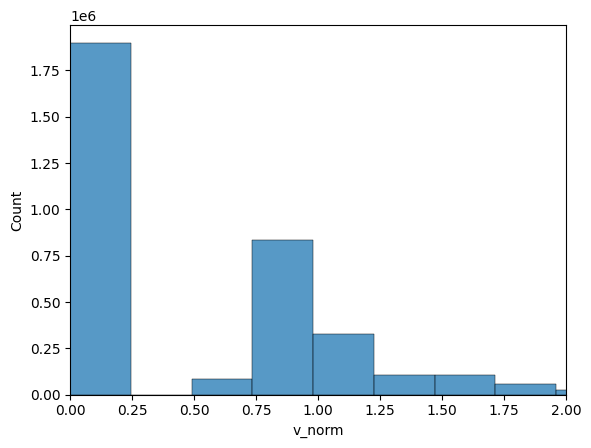

In [35]:
import seaborn as sns

sns.histplot(effort_ts["v_norm"], bins=100)
plt.xlim(0, 2)


(0.0, 3.0)

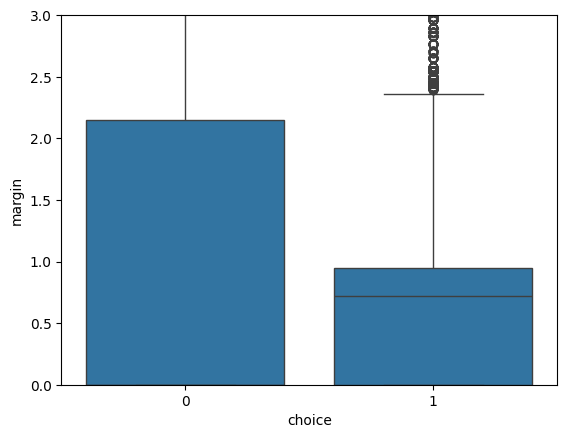

In [36]:
sns.boxplot(x="choice", y="margin", data=effort_ts.sample(200_000))
plt.ylim(0, 3)


## Quick check on the model:

In [39]:
from scipy.stats import zscore

effort_ts["H"] = (
    0.6 * zscore(effort_ts["startDistance"]) +
    0.4 * zscore(effort_ts["threat"])
)


In [40]:
effort_ts["H"] = np.log1p(np.exp(effort_ts["H"]))


In [43]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

sub = effort_ts.sample(300_000, random_state=0)

model = smf.glm(
    "c_it ~ H + startDistance",
    data=sub,
    family=sm.families.NegativeBinomial(),
    offset=sub["offset_cap"]
).fit()

print(model.summary())


/opt/anaconda3/envs/limaAnalysis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                   c_it   No. Observations:               300000
Model:                            GLM   Df Residuals:                   299997
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.8840e+05
Date:                Thu, 22 Jan 2026   Deviance:                   1.8202e+05
Time:                        13:14:34   Pearson chi2:                 1.54e+05
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01661
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.4173      0.014    -99.815

In [54]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../../data/raw/pos_ts.parquet")

# Keep only player positions at trial start
start_df = df[(df["agent"] == "player") & (df["t"] == 0)].copy()

# Compute radial distance from logged x,y
start_df["r_xy"] = np.sqrt(start_df["x"]**2 + start_df["y"]**2)

summary = (
    start_df
    .groupby("startDistance")["r_xy"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
    .sort_values("startDistance")
)

print(summary)



   startDistance  count      mean       std       min        max
0              5  14038  3.854627  0.460711  2.073213   5.967655
1              7   5443  5.990520  0.435012  4.407141   8.444511
2              9   4778  7.994565  0.423299  6.326985  10.100370


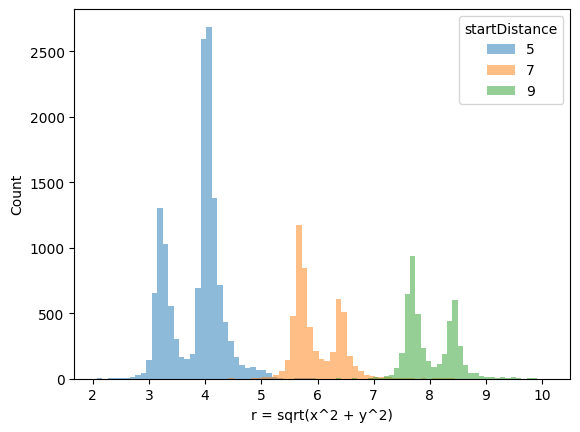

In [55]:
import matplotlib.pyplot as plt

for d, g in start_df.groupby("startDistance"):
    plt.hist(g["r_xy"], bins=40, alpha=0.5, label=f"{d}")

plt.xlabel("r = sqrt(x^2 + y^2)")
plt.ylabel("Count")
plt.legend(title="startDistance")
plt.show()


In [ ]:
import numpy as np

K = 10 #~300ms window

def add_distance_ratio(g):
    g = g.sort_values("t").copy()
    r = np.sqrt(g["x"].values**2 + g["y"].values**2)

    r_start = np.median(r[:K])
    D0 = float(g["startDistance"].iloc[0])

    g["d_hat"] = D0 * (r / r_start)
    return g


In [64]:
import numpy as np
import pandas as pd

DT_BIN = 0.150
K = 10  # ~300 ms at 33 Hz

def add_d_safety(g):
    # g is one (trial_id, entity)
    g = g.sort_values("t").copy()

    r = np.sqrt(g["x"].values**2 + g["y"].values**2)

    # robust endpoint windows
    K_eff = min(K, len(r)//3)
    if K_eff < 3:
        g["d_safety_raw"] = np.nan
        return g

    r_start = np.median(r[:K_eff])
    r_end   = np.median(r[-K_eff:])
    D0 = float(g["startDistance"].iloc[0])

    denom = (r_start - r_end)
    if denom <= 1e-6:
        g["d_safety_raw"] = np.nan
        return g

    d = D0 * (r - r_end) / denom
    g["d_safety_raw"] = np.maximum(d, 0.0)
    return g

# Apply per trial + entity
df = df.sort_values(["trial","agent","t","participantID"])
df = df.groupby(["trial","agent"], group_keys=False).apply(add_d_safety)

# Create 150ms bin index (relative time)
df["bin150"] = (df["t"] / DT_BIN).astype(int)


/var/folders/q5/85w60mr92jnbzz1hctrdmb480000gn/T/ipykernel_23189/2786477500.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["trial","agent"], group_keys=False).apply(add_d_safety)


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your parquet
pos = pd.read_parquet("../../data/raw/pos_ts.parquet")

K = 10   # ~300 ms window at ~33 Hz


def add_distance_raw(g):
    g = g.sort_values("t").copy()
    r = np.sqrt(g["x"].values**2 + g["y"].values**2)

    if len(r) < 1:
        g["d_raw"] = np.nan
        return g

    r_start = r[0]
    D0 = float(g["startDistance"].iloc[0])

    if r_start <= 1e-6:
        g["d_raw"] = np.nan
        return g

    d = D0 * (r / r_start)
    g["d_raw"] = np.maximum(d, 0.0)
    return g

# Compute distance per trial × entity
pos = pos.sort_values(["trial", "agent", "t"])
pos = pos.groupby(["trial", "agent"], group_keys=False).apply(add_distance_raw)

# Keep player only
player = pos[pos["agent"] == "player"].copy()




/var/folders/q5/85w60mr92jnbzz1hctrdmb480000gn/T/ipykernel_23189/3809381782.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pos = pos.groupby(["trial", "agent"], group_keys=False).apply(add_distance_raw)


In [85]:
first_dt = (
    player.sort_values(["trial", "t"])  # sort by trial AND t
          .groupby("trial")
          .first()
          .reset_index()
)

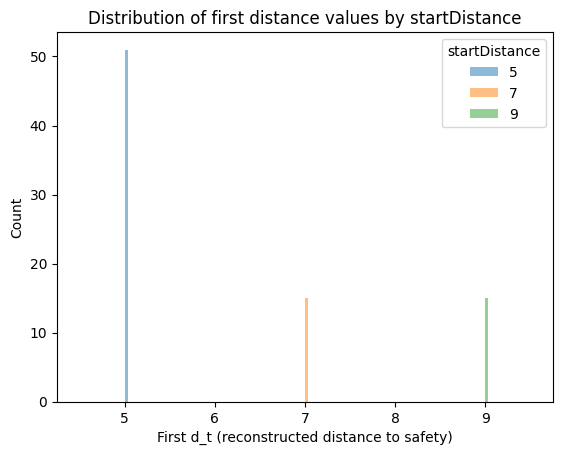

In [86]:
plt.figure()

for sd, g in first_dt.groupby("startDistance"):
    plt.hist(
        g["d_raw"].dropna(),
        bins=30,
        alpha=0.5,
        label=f"{sd}"
    )

plt.xlabel("First d_t (reconstructed distance to safety)")
plt.ylabel("Count")
plt.title("Distribution of first distance values by startDistance")
plt.legend(title="startDistance")
plt.show()


Participant: 6735cd25bd2658d4459e779b, Trial: 30


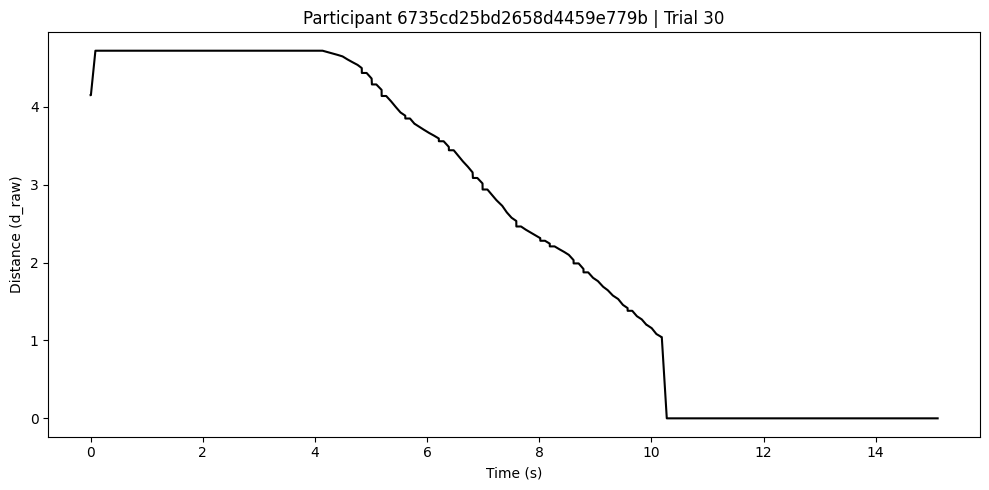

In [106]:

# Randomly sample one participant/trial
unique_trials = player[['participantID', 'trial']].drop_duplicates()
sample = unique_trials.sample(1).iloc[0]
pid, trial = sample['participantID'], sample['trial']

print(f"Participant: {pid}, Trial: {trial}")

# Filter and plot
trial_data = player[(player['participantID'] == pid) & (player['trial'] == trial)].sort_values('t')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trial_data['t'], trial_data['d_raw'], 'k-', linewidth=1.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Distance (d_raw)')
ax.set_title(f'Participant {pid} | Trial {trial}')
plt.tight_layout()
plt.show()